# ***Kodon Kullanım Frekanslarına Dayalı Canlı Sınıflandırması: HistGradientBoosting Ensemble Yaklaşımı***

**Projenin Amacı ve Kapsamı**
Bu çalışmanın temel amacı, canlıların DNA dizilimlerindeki kodon kullanım frekanslarını (codon usage bias) analiz ederek, bu canlıları biyolojik taksonomiye uygun şekilde Krallık (Kingdom) düzeyinde sınıflandırmaktır. Genetik kodun evrensel olmasına rağmen, farklı organizmaların aynı amino asitleri kodlarken tercih ettikleri kodonlar (örneğin; Lösin için CTT yerine CTC kullanımı) türe özgü farklılıklar gösterir. Bu proje, söz konusu genetik "parmak izlerini" makine öğrenmesi algoritmalarıyla çözmeyi hedeflemektedir.

**Neden HistGradientBoosting (HGB) Modeli Seçildi?**
Sınıflandırma problemi için Ensemble Learning (Topluluk Öğrenmesi) ailesinin modern ve güçlü bir üyesi olan Histogram-Based Gradient Boosting algoritması tercih edilmiştir. Bu seçimin temel nedenleri şunlardır:

*   **Dengesiz Veri Yönetimi (Imbalance Handling):** Veri setimizde bazı krallıklar (örn. Bakteriler) binlerce örneğe sahipken, bazıları (örn. Plazmidler) çok az örneğe sahiptir. HGB modeli, class_weight='balanced' parametresi ile azınlık sınıflarına yapılan hataları daha ağır cezalandırarak, modelin sadece çoğunluk sınıfını ezberlemesini engeller.

*   **Yüksek Performans ve Hız:** Büyük veri setlerinde (n > 10,000), klasik Gradient Boosting yöntemlerine (GBM) kıyasla çok daha hızlıdır. Sürekli değişkenleri histogram kutularına (bins) ayırarak işlediği için hesaplama maliyeti düşüktür.

*   **Overfitting (Aşırı Öğrenme) Kontrolü:** Dahili early_stopping ve L2 regularization mekanizmaları sayesinde, modelin eğitim verisine aşırı uyum sağlaması engellenmiş ve genelleme yeteneği artırılmıştır.

In [1]:
# Gerekli Kütüphanelerin Yüklenmesi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from IPython.display import display


sns.set_style("whitegrid")

Veri Seti Boyutu: (13028, 69)


C:\Users\fidan\AppData\Local\Temp\ipykernel_7968\1476341141.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')


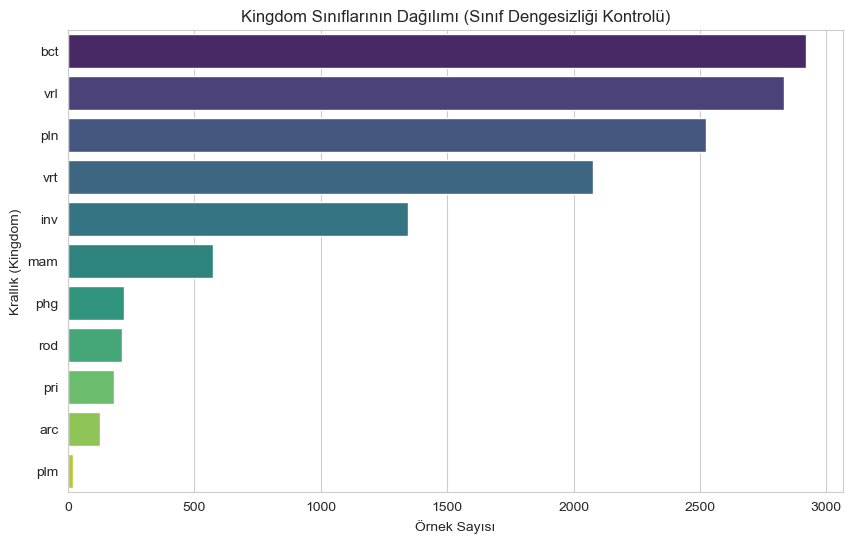

,Kingdom,DNAtype,SpeciesID,Ncodons,SpeciesName,UUU,UUC,UUA,UUG,CUU,...,CGG,AGA,AGG,GAU,GAC,GAA,GAG,UAA,UAG,UGA
0,vrl,0,100217,1995,Epizootic haematopoietic necrosis virus,0.01654,0.01203,0.00050,0.00351,0.01203,...,0.00451,0.01303,0.03559,0.01003,0.04612,0.01203,0.04361,0.00251,0.00050,0.00000
1,vrl,0,100220,1474,Bohle iridovirus,0.02714,0.01357,0.00068,0.00678,0.00407,...,0.00136,0.01696,0.03596,0.01221,0.04545,0.01560,0.04410,0.00271,0.00068,0.00000
2,vrl,0,100755,4862,Sweet potato leaf curl virus,0.01974,0.0218,0.01357,0.01543,0.00782,...,0.00596,0.01974,0.02489,0.03126,0.02036,0.02242,0.02468,0.00391,0.00000,0.00144
3,vrl,0,100880,1915,Northern cereal mosaic virus,0.01775,0.02245,0.01619,0.00992,0.01567,...,0.00366,0.01410,0.01671,0.03760,0.01932,0.03029,0.03446,0.00261,0.00157,0.00000
4,vrl,0,100887,22831,Soil-borne cereal mosaic virus,0.02816,0.01371,0.00767,0.03679,0.01380,...,0.00604,0.01494,0.01734,0.04148,0.02483,0.03359,0.03679,0.00000,0.00044,0.00131


In [2]:
# Veri setini yükleme

df = pd.read_csv('C:\\Users\\fidan\\OneDrive\\Masaüstü\\codon_usage.csv', low_memory=False)  

print("Veri Seti Boyutu:", df.shape)

# Kingdom Sınıf Dağılımı grafik 
plt.figure(figsize=(10, 6))
sns.countplot(y='Kingdom', data=df, order=df['Kingdom'].value_counts().index, palette='viridis')
plt.title('Kingdom Sınıflarının Dağılımı (Sınıf Dengesizliği Kontrolü)')
plt.xlabel('Örnek Sayısı')
plt.ylabel('Krallık (Kingdom)')
plt.show() 

# İlk 5 satırı göstermek için 
display(df.head())

### Veri Temizliği ve Tip Dönüşümü
Veri setindeki kodon frekansları bazen sayısal olması gerekirken "string" (metin) olarak algılanabilmektedir. Bu blokta:
*   Gereksiz sütunlar (`SpeciesID`, `SpeciesName`) atılır.
*   Sayısal sütunlardaki hatalı karakterler düzeltilir ve veri tipi sayısal formata (float) çevrilir.

In [3]:
codon_cols = df.columns[5:]

other_numeric_cols = ['Ncodons', 'DNAtype']
# Tüm sayısal özellikler
numeric_features = list(codon_cols) + other_numeric_cols

print("--- Temizlik Başlangıç (Virgülden Noktaya çevirme) ---")
for col in numeric_features:
    if df[col].dtype == 'object':
        # Virgülleri noktaya çevir, sayısal tipe zorlama, hataları NaN yapma adımı
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(",", ".", regex=False), 
            errors="coerce"
        )
        
# İhtiyacımız olmayan tanımlayıcı sütunları çıkarıyoruz
df_cleaned = df.drop(columns=['SpeciesID', 'SpeciesName']).copy()

--- Temizlik Başlangıç (Virgülden Noktaya çevirme) ---


###  Veri Setinin Eğitim ve Test Olarak Ayrılması
Veri sızıntısını önlemek için veri seti, işlem yapılmadan önce %80 Eğitim ve %20 Test olarak ayrılır. Sınıf oranlarını korumak için `stratify` parametresi kullanılır.

In [4]:
#  Veri Ayırma (Split) 
X = df_cleaned.drop(columns=['Kingdom'])
y = df_cleaned['Kingdom']

# %80 Eğitim / %20 Test, Krallığa göre Katmanlı (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Eğitim ve test setlerini tek DataFrame'lerde birleştir 
train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print("\n--- Veri Ayırma Sonuçları ---")
print(f"X_train Boyutu: {X_train.shape}")
print(f"X_test Boyutu: {X_test.shape}")


--- Veri Ayırma Sonuçları ---
X_train Boyutu: (10422, 66)
X_test Boyutu: (2606, 66)


### Özellik Mühendisliği (Feature Engineering)
Mevcut verilerden yeni ve anlamlı bilgiler türetmek model başarısını artırabilir. 
Burada, DNA'daki toplam kodon sayısı (`Ncodons`) ile belirli bir kodonun (`UUU`) etkileşimini yakalamak amacıyla yeni bir özellik oluşturulmaktadır.

In [5]:

def create_interaction_feature(df):
    """Ncodons ve TTT kodon frekansı arasında çarpımsal etkileşim oluşturur."""
    
    df['Ncodons_x_UUU'] = df['Ncodons'] * df['UUU']
    return df

# Özellik yaratma işlemini train/test setlerine uygulama
train_df = create_interaction_feature(train_df)
test_df = create_interaction_feature(test_df)


numeric_features.append('Ncodons_x_UUU') 

print("\n Ncodons_x_UUU Etkileşim Özelliği Başarıyla Oluşturuldu.")



 Ncodons_x_UUU Etkileşim Özelliği Başarıyla Oluşturuldu.


### Eksik Verilerin Doldurulması ve Ölçeklendirme
*   Imputation: Eğitim setindeki eksik veriler, o sütunun ortalaması ile doldurulur. Test seti de (sızıntıyı önlemek için) eğitim setinin ortalaması ile doldurulur.
*   Encoding: Hedef değişken olan `Kingdom` sayısal değerlere dönüştürülür (Label Encoding).
*   Scaling: Veriler, ortalaması 0 ve standart sapması 1 olacak şekilde standartlaştırılır (StandardScaler). LDA gibi uzaklık ve varyans temelli algoritmalar için bu adım zorunludur.

In [6]:
train_means = train_df[numeric_features].mean()

# TRAIN ve TEST setlerini, TRAIN setinin ortalamaları ile dolduruyoruz.
train_df[numeric_features] = train_df[numeric_features].fillna(train_means)
test_df[numeric_features] = test_df[numeric_features].fillna(train_means)

print("\nEksik Değer Doldurma Tamamlandı (Test seti, Train ortalaması ile dolduruldu).")

# Encoding (Hedef Değişken Kodlama) 
le = LabelEncoder()
train_df['Kingdom_Encoded'] = le.fit_transform(train_df['Kingdom'])
test_df['Kingdom_Encoded'] = le.transform(test_df['Kingdom'])

print("Krallık Kodlaması:", dict(zip(le.classes_, le.transform(le.classes_))))

#  Scaling (Ölçeklendirme) 
scaler = StandardScaler()

scaler.fit(train_df[numeric_features])

# TRAIN ve TEST setlerini ölçekliyoruz.(TEST SADECE TRANSFORM)
train_df[numeric_features] = scaler.transform(train_df[numeric_features])
test_df[numeric_features] = scaler.transform(test_df[numeric_features])

print("Ölçeklendirme Tamamlandı (Ncodons ve Kodonlar Standardize Edildi).")


Eksik Değer Doldurma Tamamlandı (Test seti, Train ortalaması ile dolduruldu).
Krallık Kodlaması: {'arc': 0, 'bct': 1, 'inv': 2, 'mam': 3, 'phg': 4, 'plm': 5, 'pln': 6, 'pri': 7, 'rod': 8, 'vrl': 9, 'vrt': 10}
Ölçeklendirme Tamamlandı (Ncodons ve Kodonlar Standardize Edildi).


###  İşlenmiş Verinin Kaydedilmesi
Temizlenmiş ve modele girmeye hazır hale getirilmiş eğitim ve test setleri, daha sonraki aşamalarda (PCA, LDA vb.) tekrar tekrar işlem yapmamak adına ayrı dosyalar halinde kaydedilir.
Kaydedilen temiz veri setleri yüklenir ve LDA modellemesi ile özellik seçimi aşamalarına geçilir.

In [7]:
# X ve y setlerini oluşturma.
X_train_final = train_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_train_final = train_df['Kingdom_Encoded']
X_test_final = test_df.drop(columns=['Kingdom', 'Kingdom_Encoded'])
y_test_final = test_df['Kingdom_Encoded']

# Sonuçları CSV olarak kaydet
X_train_final.to_csv('X_train_final_KUSURSUZ.csv', index=False)
X_test_final.to_csv('X_test_final_KUSURSUZ.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_train_final.values, 'Kingdom_Original': train_df['Kingdom'].values}).to_csv('y_train_encoded_final_KUSURSUZ.csv', index=False)
pd.DataFrame({'Kingdom_Encoded': y_test_final.values, 'Kingdom_Original': test_df['Kingdom'].values}).to_csv('y_test_encoded_final_KUSURSUZ.csv', index=False)

print("Tüm hazırlık adımları tamamlandı. Verileriniz 'KUSURSUZ' etiketli dosyalara kaydedilmiştir.")

Tüm hazırlık adımları tamamlandı. Verileriniz 'KUSURSUZ' etiketli dosyalara kaydedilmiştir.


In [8]:

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, brier_score_loss


#  Veri Yükleme (Standardize Edilmiş) 
X_train = pd.read_csv('X_train_final_KUSURSUZ.csv')
X_test = pd.read_csv('X_test_final_KUSURSUZ.csv')
y_train = pd.read_csv('y_train_encoded_final_KUSURSUZ.csv')['Kingdom_Encoded']
y_test = pd.read_csv('y_test_encoded_final_KUSURSUZ.csv')['Kingdom_Encoded']
TARGET_CLASSES = len(y_test.unique())


###  Dengeli (Balanced) ***HistGradientBoosting Modeli***
Bu bölümde,çok sayıda karar ağacını birleştiren güçlü bir Ensemble (Topluluk) yöntemi olan `HistGradientBoostingClassifier` eğitilir.

*   Neden Bu Model? Büyük veri setlerinde hızlıdır, doğrusal olmayan karmaşık ilişkileri yakalayabilir ve eksik verileri (NaN) doğal olarak yönetebilir.
*   Class Weight (Balanced): Veri setindeki sınıf dengesizliği problemini (bazı türlerin çok, bazılarının az olması) çözmek için bu parametre kritik öneme sahiptir. Azınlık sınıflarına daha fazla ağırlık vererek modelin onları "görmezden gelmesini" engeller.
*   Regularization (L2): Modelin veriyi ezberlemesini (overfitting) önlemek ve genelleme yeteneğini artırmak için L2 cezası (1.5) uygulanmıştır.
*   Early Stopping: Eğitim sırasında modelin performansı iyileşmeyi durdurursa, eğitim otomatik olarak kesilerek hem zaman kazanılır hem de aşırı öğrenmenin önüne geçilir.

In [9]:
#  Gerekli Kütüphaneler 
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                             roc_auc_score, matthews_corrcoef, roc_curve, auc)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

#  Hiperparametre tunung ve Model eğitimi ( Gridsearch ile)

print("Hiperparametre optimizasyonu (Grid Search) başlatılıyor...")
print("Farklı parametre kombinasyonları denenip en iyisi seçilecek...")

# 1. Sabit kalacak temel ayarlar
hgb_base = HistGradientBoostingClassifier(
    random_state=42,
    class_weight='balanced',  
    early_stopping=True,      
    scoring='loss'            
)

# 2. Denenecek parametreler listesi 
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],    # Öğrenme hızı
    'max_iter': [100, 200, 300],          # Ağaç sayısı
    'max_depth': [None, 10, 20],          # Derinlik
    'l2_regularization': [0, 1.5]         # Ceza katsayısı
}

# 3. Grid Search Kurulumu (Modelleri Yarıştırma)
grid_search = GridSearchCV(
    estimator=hgb_base,
    param_grid=param_grid,
    cv=3,                     # 3 katlı çapraz doğrulama
    scoring='f1_weighted',    # Başarı kriteri (Dengesiz veri için F1 seçtik)
    n_jobs=-1,                # Hız için tüm işlemcileri kullan
    verbose=1
)

# 4. Modeli Eğit ve En İyisini Bul
grid_search.fit(X_train, y_train)

# 5. Sonuçları Yazdır
print("\n" + "="*50)
print("EN İYİ PARAMETRELER BULUNDU")
print("="*50)
print(f"En İyi CV Skoru (F1-Weighted): {grid_search.best_score_:.4f}")
print("Seçilen Parametreler:")
for param, val in grid_search.best_params_.items():
    print(f"  - {param}: {val}")

print("\nEğitim tamamlandı. En iyi model 'grid_search.best_estimator_' içinde saklandı.")

Hiperparametre optimizasyonu (Grid Search) başlatılıyor...
Farklı parametre kombinasyonları denenip en iyisi seçilecek...
Fitting 3 folds for each of 54 candidates, totalling 162 fits

EN İYİ PARAMETRELER BULUNDU
En İyi CV Skoru (F1-Weighted): 0.8961
Seçilen Parametreler:
  - l2_regularization: 0
  - learning_rate: 0.1
  - max_depth: None
  - max_iter: 100

Eğitim tamamlandı. En iyi model 'grid_search.best_estimator_' içinde saklandı.


### Performans Analizi ve Model Değerlendirmesi

Modelin eğitim süreci tamamlandıktan sonra, modelin hiç görmediği Test Seti kullanılarak gerçek dünya performansı ölçülmüştür. Bu aşamada amaç, modelin ezber mi yaptığını (Overfitting) yoksa veriyi gerçekten mi öğrendiğini test etmektir.

**Değerlendirme Yöntemi:**
Sadece genel doğruluğa (Accuracy) bakmak yanıltıcı olabileceğinden, özellikle dengesiz veri setlerinde modelin güvenilirliğini ölçen MCC (Matthews Correlation Coefficient) ve sınıfları ayırt etme gücünü gösteren ROC AUC metrikleri temel alınmıştır.

Aşağıdaki kod bloğu ile sayısal başarı raporları oluşturulmuş ve sonuçlar Confusion Matrix (Hata Matrisi) ile görselleştirilerek modelin hangi sınıfları birbirine karıştırdığı detaylandırılmıştır.

Test seti üzerinde tahminler yapılıyor...

HISTGRADIENTBOOSTING MODEL PERFORMANS RAPORU (EN İYİ MODEL)
              precision    recall  f1-score   support

         arc     0.8182    0.7200    0.7660        25
         bct     0.9506    0.9555    0.9530       584
         inv     0.8745    0.8030    0.8372       269
         mam     0.9151    0.8509    0.8818       114
         phg     0.8857    0.7045    0.7848        44
         plm     0.0000    0.0000    0.0000         4
         pln     0.9286    0.9267    0.9277       505
         pri     0.8000    0.6667    0.7273        36
         rod     0.8378    0.7209    0.7750        43
         vrl     0.9091    0.9700    0.9386       567
         vrt     0.9372    0.9711    0.9538       415

    accuracy                         0.9194      2606
   macro avg     0.8052    0.7536    0.7768      2606
weighted avg     0.9180    0.9194    0.9179      2606

Matthews Correlation Coefficient (MCC): 0.9023
Macro Average ROC AUC Score       : 0

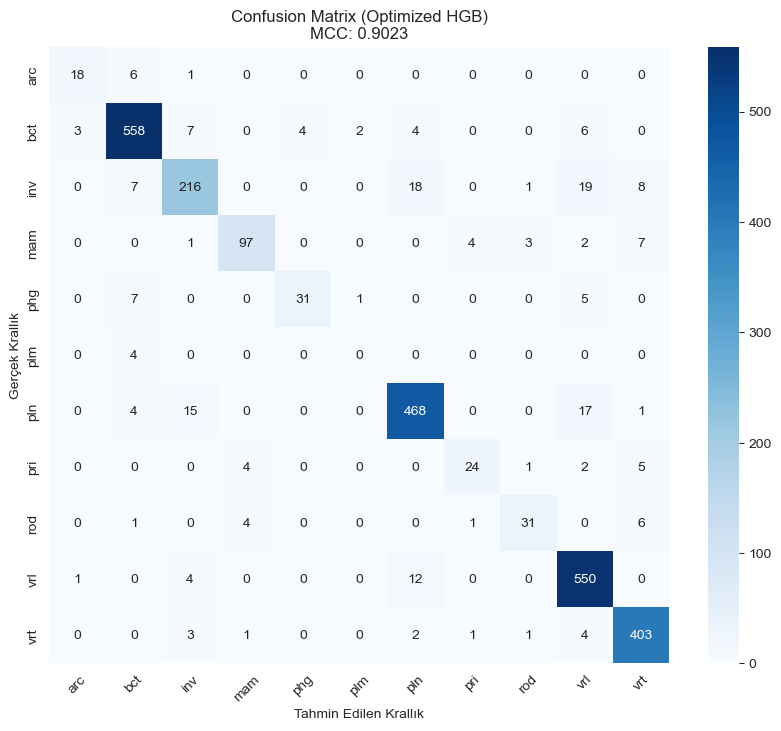

C:\Users\fidan\AppData\Local\Temp\ipykernel_7968\4067064225.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


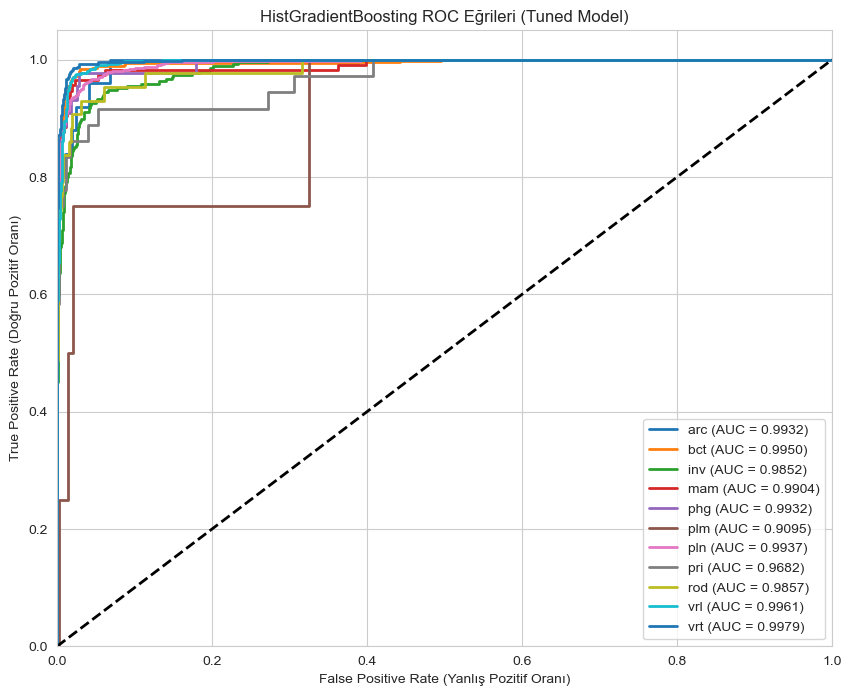

In [10]:
# Test, Performans raporu ve Görselleştirme

# En iyi modeli seçiyoruz
best_model = grid_search.best_estimator_

# -> Tahminlerin yapılması
print("Test seti üzerinde tahminler yapılıyor...")
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test) 
 
print("\n" + "="*80)
print("HISTGRADIENTBOOSTING MODEL PERFORMANS RAPORU (EN İYİ MODEL)")
print("="*80)

# target_names parametresi için le.classes_ kullanıyoruz (LabelEncoder nesnenin adı 'le' ise)
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))

mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    print(f"Macro Average ROC AUC Score       : {roc_auc:.4f}")
except ValueError:
    print("ROC AUC hesaplanamadı.")

acc = accuracy_score(y_test, y_pred)
print(f"Genel Doğruluk (Accuracy)           : {acc:.4f}")
print("="*80)


# A) Confusion Matrix (Karmaşıklık Matrisi)
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_) 

plt.title(f'Confusion Matrix (Optimized HGB)\nMCC: {mcc:.4f}')
plt.xlabel('Tahmin Edilen Krallık')
plt.ylabel('Gerçek Krallık')
plt.xticks(rotation=45) 
plt.show()

# B) ROC Eğrileri
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    # Sadece test setinde var olan sınıfları çiz
    if np.sum(y_test_bin[:, i]) > 0: 
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[i]} (AUC = {roc_auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('HistGradientBoosting ROC Eğrileri (Tuned Model)')
plt.legend(loc="lower right")
plt.show()